In [1]:
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn
import torch.nn.functional as F

from astropy.io import fits
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [3]:
class CNN1D_RFI_256_logits(nn.Module):
    """
    Input:  (N, 1, 256)
    Output: (N, 1)  (logits)
    """
    def __init__(self, dropout=0.5):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 64, 7)        # 256 -> 250
        self.pool1 = nn.MaxPool1d(2, 2)         # 250 -> 125
        self.conv2 = nn.Conv1d(64, 128, 7)      # 125 -> 119
        self.pool2 = nn.MaxPool1d(2, 2)         # 120 -> 60 (после pad)
        self.conv3 = nn.Conv1d(128, 256, 10)    # 60 -> 51
        self.pool3 = nn.MaxPool1d(2, 2)         # 51 -> 25

        self.fc1 = nn.Linear(6400, 256)         # 25*256=6400
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = F.pad(x, (0, 1))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        logits = self.fc2(x)
        return logits

In [4]:
ckpt = torch.load("best_model_by_acc.pt", map_location=device)

model = CNN1D_RFI_256_logits(dropout=0.5).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

CNN1D_RFI_256_logits(
  (conv1): Conv1d(1, 64, kernel_size=(7,), stride=(1,))
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 128, kernel_size=(7,), stride=(1,))
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 256, kernel_size=(10,), stride=(1,))
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6400, out_features=256, bias=True)
  (drop): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)

In [5]:
thr = 0.5
nsamp_default = 256

In [6]:
def preprocess_one(x_np, normalize=True):
    """
    x_np: (W,)
    Вернёт tensor: (1, 1, W)
    """
    x = np.asarray(x_np, dtype=np.float32)

    if x.ndim != 1:
        raise ValueError(f"Expected 1D array, got shape {x.shape}")

    if normalize:
        m = float(x.max())
        if m < 1e-8:
            m = 1.0
        x = x / m

    x = torch.from_numpy(x)   # (W,)
    x = x.unsqueeze(0)        # (1, W)
    x = x.unsqueeze(0)        # (1, 1, W)
    return x


def make_predict_one(model, device, threshold=0.9, normalize=True):
    """
    Возвращает функцию:
        pred, prob = predict_one(row)
    где row имеет форму (W,)
    """
    model.eval()

    @torch.no_grad()
    def predict_one(x_np):
        x = preprocess_one(x_np, normalize=normalize).to(device, non_blocking=True)
        logits = model(x)
        prob = torch.sigmoid(logits).view(-1).item()
        pred = int(prob >= threshold)
        return pred, prob

    return predict_one


def preprocess_rows_batch(data_hw: np.ndarray, normalize=True):
    """
    data_hw: (H, W)
    Вернёт tensor: (H, 1, W)
    """
    x = np.asarray(data_hw, dtype=np.float32)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {x.shape}")

    if normalize:
        m = x.max(axis=1, keepdims=True)
        m = np.where(m < 1e-8, 1.0, m)
        x = x / m

    xt = torch.from_numpy(x)   # (H, W)
    xt = xt.unsqueeze(1)       # (H, 1, W)
    return xt


def make_predict_segment_batched(model, device, threshold=0.9, normalize=True):
    """
    Возвращает функцию:
        row_mask, probs = predict_segment_fn(data_ct)

    где data_ct имеет форму (nchan, nsamp)
    row_mask: (nchan,) bool
    probs:    (nchan,) float
    """
    model.eval()

    @torch.no_grad()
    def predict_segment_fn(data_ct: np.ndarray):
        x = preprocess_rows_batch(data_ct, normalize=normalize).to(device, non_blocking=True)
        logits = model(x)                        # ожидаем (H,1) или (H,)
        probs = torch.sigmoid(logits).view(-1).detach().cpu().numpy().astype(np.float32)
        row_mask = probs >= threshold
        return row_mask, probs

    return predict_segment_fn


def make_predict_segment_rowwise(predict_one):
    """
    Возвращает функцию:
        row_mask, probs = predict_segment_fn(data_ct)

    где data_ct имеет форму (nchan, nsamp)
    """
    def predict_segment_fn(data_ct: np.ndarray):
        out = [predict_one(row) for row in data_ct]
        row_mask = np.array([bool(pred) for pred, _ in out], dtype=bool)
        probs = np.array([float(prob) for _, prob in out], dtype=np.float32)
        return row_mask, probs

    return predict_segment_fn


def copy_psrfits_file(src, dst=None, suffix="_masked", overwrite=False):
    src = Path(src)

    if dst is None:
        dst = src.with_name(f"{src.stem}{suffix}{src.suffix}")
    else:
        dst = Path(dst)

    if dst.exists() and not overwrite:
        raise FileExistsError(f"File already exists: {dst}")

    shutil.copy2(src, dst)
    return str(dst)


def get_fits_layout(fits_file, nsamp):
    with fits.open(fits_file, memmap=True) as hdul:
        data = hdul["SUBINT"].data["DATA"]   # (nsubint, nsblk, npol, nchan)
        nsubint, nsblk, npol, nchan = data.shape

    total_samples = nsubint * nsblk
    n_complete_segments = total_samples // nsamp
    tail_samples = total_samples % nsamp

    return {
        "nsubint": nsubint,
        "nsblk": nsblk,
        "npol": npol,
        "nchan": nchan,
        "total_samples": total_samples,
        "nsamp": nsamp,
        "n_complete_segments": n_complete_segments,
        "tail_samples": tail_samples,
    }


def read_segment_from_data_array(data_array, index, nsamp, pol=0):
    """
    data_array: hdul["SUBINT"].data["DATA"] с формой (nsubint, nsblk, npol, nchan)

    Возвращает:
    - segment_ct: (nchan, nsamp)
    - seg_info: dict с индексами для обратной записи
    """
    nsubint, nsblk, npol, nchan = data_array.shape
    total_samples = nsubint * nsblk

    if not (0 <= pol < npol):
        raise IndexError(f"pol={pol} is out of range for npol={npol}")

    position = index * nsamp
    if position + nsamp > total_samples:
        raise IndexError(
            f"Segment index={index} with nsamp={nsamp} exceeds total_samples={total_samples}"
        )

    subint_start = position // nsblk
    subint_end = (position + nsamp - 1) // nsblk + 1
    local_start = position - subint_start * nsblk

    chunk_tc = data_array[subint_start:subint_end, :, pol, :].reshape(-1, nchan).copy()   # (time, chan)
    segment_tc = chunk_tc[local_start:local_start + nsamp]                                  # (nsamp, chan)
    segment_ct = segment_tc.T.copy()                                                        # (chan, nsamp)

    seg_info = {
        "index": index,
        "position": position,
        "nsamp": nsamp,
        "nchan": nchan,
        "subint_start": subint_start,
        "subint_end": subint_end,
        "local_start": local_start,
        "nsblk": nsblk,
        "pol": pol,
    }

    return segment_ct, seg_info


def write_segment_to_data_array(data_array, segment_ct, seg_info):
    """
    Записывает segment_ct формы (nchan, nsamp) обратно в data_array.
    """
    nsubint, nsblk, npol, nchan = data_array.shape

    expected_shape = (seg_info["nchan"], seg_info["nsamp"])
    if segment_ct.shape != expected_shape:
        raise ValueError(
            f"segment_ct has shape {segment_ct.shape}, expected {expected_shape}"
        )

    subint_start = seg_info["subint_start"]
    subint_end = seg_info["subint_end"]
    local_start = seg_info["local_start"]
    pol = seg_info["pol"]

    chunk_tc = data_array[subint_start:subint_end, :, pol, :].reshape(-1, nchan).copy()
    chunk_tc[local_start:local_start + seg_info["nsamp"], :] = segment_ct.T.astype(
        data_array.dtype, copy=False
    )

    data_array[subint_start:subint_end, :, pol, :] = chunk_tc.reshape(
        subint_end - subint_start,
        nsblk,
        nchan
    )
    
    
def get_data_any(file_or_path, index, nsamp, pol=0):
    """
    Возвращает один сегмент в форме (nchan, nsamp).
    """
    # FITS/PSRFITS по пути
    if isinstance(file_or_path, (str, os.PathLike)):
        path = os.fspath(file_or_path)
        if path.lower().endswith((".fits", ".sf")):
            with fits.open(path, memmap=True) as hdul:
                data_array = hdul["SUBINT"].data["DATA"]
                segment_ct, _ = read_segment_from_data_array(data_array, index=index, nsamp=nsamp, pol=pol)
                return segment_ct

    # your-like object
    if hasattr(file_or_path, "get_data"):
        position = index * nsamp
        return file_or_path.get_data(nstart=position, nsamp=nsamp).T

    raise TypeError("file_or_path must be a FITS path or an object with .get_data().")


def apply_mask_from_row_mask(data_ct, row_mask, filler="zero", random_seed=42):
    """
    data_ct:  (nchan, nsamp)
    row_mask: (nchan,) bool
    """
    data_ct = np.asarray(data_ct)
    row_mask = np.asarray(row_mask, dtype=bool)

    nchan, nsamp = data_ct.shape
    if row_mask.shape != (nchan,):
        raise ValueError(f"row_mask shape {row_mask.shape} does not match nchan={nchan}")

    data_masked = data_ct.copy()

    if filler == "zero":
        data_masked[row_mask, :] = 0

    elif filler == "noise":
        clean_rows = data_ct[~row_mask, :]

        if clean_rows.size == 0:
            mu = float(np.mean(data_ct))
            sigma = float(np.std(data_ct))
        else:
            mu = float(np.mean(clean_rows))
            sigma = float(np.std(clean_rows))

        rng = np.random.default_rng(random_seed)
        noise = rng.normal(
            loc=mu,
            scale=max(sigma, 1e-6),
            size=(int(row_mask.sum()), nsamp),
        )

        noise = np.clip(noise, data_ct.min(), data_ct.max())
        data_masked[row_mask, :] = noise.astype(data_ct.dtype, copy=False)

    else:
        raise ValueError("filler must be 'zero' or 'noise'")

    return data_masked



def apply_mask_to_segment(data_ct, predict_segment_fn, filler="zero", random_seed=42):
    """
    data_ct: (nchan, nsamp)

    predict_segment_fn должен вернуть:
    - row_mask: (nchan,) bool
    - probs:    (nchan,) float
    """
    row_mask, probs = predict_segment_fn(data_ct)

    row_mask = np.asarray(row_mask, dtype=bool)
    probs = np.asarray(probs, dtype=np.float32)

    nchan = data_ct.shape[0]
    if row_mask.shape != (nchan,):
        raise ValueError(f"row_mask shape {row_mask.shape} does not match nchan={nchan}")
    if probs.shape != (nchan,):
        raise ValueError(f"probs shape {probs.shape} does not match nchan={nchan}")

    data_masked = apply_mask_from_row_mask(
        data_ct,
        row_mask=row_mask,
        filler=filler,
        random_seed=random_seed,
    )

    return data_masked, row_mask, probs


def plot_masked_segment(
    file_or_path,
    index,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    title="",
    plot=True,
    save_path=None,
):
    """
    Читает один сегмент, применяет маску, НО НЕ ПИШЕТ В ФАЙЛ.

    Возвращает:
    - original_data : (nchan, nsamp)
    - masked_data   : (nchan, nsamp)
    - row_mask      : (nchan,)
    - probs         : (nchan,)
    """
    data_ct = get_data_any(file_or_path, index=index, nsamp=nsamp, pol=pol)

    data_masked_ct, row_mask, probs = apply_mask_to_segment(
        data_ct=data_ct,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
    )

    if plot:
        overlay = np.repeat(row_mask[:, None], data_ct.shape[1], axis=1).astype(float)
        cmap_black = ListedColormap([(0, 0, 0, 0.0), (0, 0, 0, 1.0)])

        vmin = float(np.min(data_ct))
        vmax = float(np.max(data_ct))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
        fig.suptitle(f"Index {index} {title}".strip(), fontsize=13)

        ax1.imshow(
            data_ct,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
            origin="upper",
        )
        ax1.set_title("Original")
        ax1.set_xlabel("Time samples")
        ax1.set_ylabel("Channel")

        ax2.imshow(
            data_masked_ct,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
            origin="upper",
        )
        ax2.imshow(
            overlay,
            cmap=cmap_black,
            vmin=0,
            vmax=1,
            aspect="auto",
            origin="upper",
        )
        ax2.set_title(f"Masked ({filler})")
        ax2.set_xlabel("Time samples")

        plt.tight_layout()

        if save_path is not None:
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=250, bbox_inches="tight")
        else:
            plt.show()

    return data_ct, data_masked_ct, row_mask, probs


def write_one_masked_segment_to_fits(
    fits_file,
    index,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify=True,
):
    """
    Читает один сегмент, маскирует, записывает обратно.

    verify=True:
    после записи перечитывает тот же сегмент и проверяет точное совпадение.
    """
    with fits.open(fits_file, memmap=True, mode="update") as hdul:
        data_array = hdul["SUBINT"].data["DATA"]

        original_data_ct, seg_info = read_segment_from_data_array(
            data_array,
            index=index,
            nsamp=nsamp,
            pol=pol,
        )

        masked_data_ct, row_mask, probs = apply_mask_to_segment(
            data_ct=original_data_ct,
            predict_segment_fn=predict_segment_fn,
            filler=filler,
            random_seed=random_seed,
        )

        write_segment_to_data_array(data_array, masked_data_ct, seg_info)
        hdul.flush()

    if verify:
        reread_data_ct = get_data_any(fits_file, index=index, nsamp=nsamp, pol=pol)
        if not np.array_equal(masked_data_ct, reread_data_ct):
            diff = np.abs(
                masked_data_ct.astype(np.int64) - reread_data_ct.astype(np.int64)
            )
            raise RuntimeError(
                "Round-trip verification failed.\n"
                f"max|diff| = {diff.max()}, n_diff = {(diff != 0).sum()}"
            )

    return original_data_ct, masked_data_ct, row_mask, probs


def process_fits_segments(
    fits_file,
    indices,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify_every=None,
    desc="Applying mask",
):
    """
    Обрабатывает произвольный набор segment-index'ов.

    indices: iterable индексов сегментов
    verify_every:
        None  -> не проверять
        1     -> проверять каждый сегмент
        10    -> каждый 10-й сегмент
    """
    indices = list(indices)
    stats = []

    with fits.open(fits_file, memmap=True, mode="update") as hdul:
        data_array = hdul["SUBINT"].data["DATA"]
        nsubint, nsblk, npol, nchan = data_array.shape
        total_samples = nsubint * nsblk
        n_complete_segments = total_samples // nsamp

        pbar = tqdm(indices, desc=desc, unit="segment")

        for i, index in enumerate(pbar, start=1):
            if not (0 <= index < n_complete_segments):
                raise IndexError(
                    f"index={index} is out of range [0, {n_complete_segments - 1}]"
                )

            original_data_ct, seg_info = read_segment_from_data_array(
                data_array,
                index=index,
                nsamp=nsamp,
                pol=pol,
            )

            # Чтобы noise filler не повторял один и тот же шум для всех сегментов
            seed_i = None if random_seed is None else int(random_seed + index)

            masked_data_ct, row_mask, probs = apply_mask_to_segment(
                data_ct=original_data_ct,
                predict_segment_fn=predict_segment_fn,
                filler=filler,
                random_seed=seed_i,
            )

            write_segment_to_data_array(data_array, masked_data_ct, seg_info)

            if verify_every is not None and verify_every > 0 and (i % verify_every == 0):
                reread_data_ct, _ = read_segment_from_data_array(
                    data_array,
                    index=index,
                    nsamp=nsamp,
                    pol=pol,
                )

                if not np.array_equal(masked_data_ct, reread_data_ct):
                    diff = np.abs(
                        masked_data_ct.astype(np.int64) - reread_data_ct.astype(np.int64)
                    )
                    raise RuntimeError(
                        f"Verification failed at index={index}. "
                        f"max|diff|={diff.max()}, n_diff={(diff != 0).sum()}"
                    )

            stats.append({
                "index": int(index),
                "n_masked": int(row_mask.sum()),
                "frac_masked": float(row_mask.mean()),
                "prob_min": float(probs.min()),
                "prob_mean": float(probs.mean()),
                "prob_max": float(probs.max()),
            })

            pbar.set_postfix(masked=int(row_mask.sum()))

        hdul.flush()

    return pd.DataFrame(stats)



def mask_one_index_in_fits(
    fits_file,
    index,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify=True,
):
    stats_df = process_fits_segments(
        fits_file=fits_file,
        indices=[index],
        nsamp=nsamp,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
        pol=pol,
        verify_every=1 if verify else None,
        desc=f"Masking index {index}",
    )
    return stats_df


def mask_indices_in_fits(
    fits_file,
    indices,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify_every=None,
):
    return process_fits_segments(
        fits_file=fits_file,
        indices=indices,
        nsamp=nsamp,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
        pol=pol,
        verify_every=verify_every,
        desc="Masking selected indices",
    )


def mask_index_range_in_fits(
    fits_file,
    index_start,
    index_stop,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify_every=None,
):
    """
    Обрабатывает индексы:
        index_start, index_start+1, ..., index_stop-1
    """
    if index_stop < index_start:
        raise ValueError("index_stop must be >= index_start")

    return process_fits_segments(
        fits_file=fits_file,
        indices=range(index_start, index_stop),
        nsamp=nsamp,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
        pol=pol,
        verify_every=verify_every,
        desc=f"Masking range [{index_start}, {index_stop})",
    )


def mask_full_fits(
    fits_file,
    nsamp,
    predict_segment_fn,
    filler="zero",
    random_seed=42,
    pol=0,
    verify_every=None,
):
    layout = get_fits_layout(fits_file, nsamp=nsamp)
    n_complete_segments = layout["n_complete_segments"]

    if layout["tail_samples"] != 0:
        print(
            f"Warning: total_samples is not divisible by nsamp. "
            f"Tail of {layout['tail_samples']} samples will be ignored."
        )

    return process_fits_segments(
        fits_file=fits_file,
        indices=range(n_complete_segments),
        nsamp=nsamp,
        predict_segment_fn=predict_segment_fn,
        filler=filler,
        random_seed=random_seed,
        pol=pol,
        verify_every=verify_every,
        desc="Masking full file",
    )

# Создаем предикторы

In [51]:
predict_one = make_predict_one(
    model=model,
    device=device,
    threshold=thr,
    normalize=True,
)

predict_segment_rowwise = make_predict_segment_rowwise(predict_one)

predict_segment_batched = make_predict_segment_batched(
    model=model,
    device=device,
    threshold=thr,
    normalize=True,
)

In [52]:
predict_segment_fn = predict_segment_batched

In [7]:
directory = '/hercules/results/akazantsev/filterbank_files/B0531+21/'
filename = 'B0531+21_59000_48386_for_rfiweather_test.fits'
src_file = f'{directory}{filename}' # B0531+21_59000_48386

# src_file = '/hercules/results/akazantsev/filterbank_files/B0531+21/B0531+21_60482_57794.fits' # B0531+21_60482_57794
src_file = '/hercules/results/akazantsev/filterbank_files/B0355+54_60285/B0355+54_60285.fits' # B0355+54_60285
# src_file = '/hercules/results/akazantsev/filterbank_files/B1933+16/B1933+16_59475_68410.fits'
# src_file = '/hercules/results/akazantsev/filterbank_files/FRB20240114A/FRB20240114A_60384.fits'

noise_mode = ['zero', 'noise'][0]

In [64]:
work_file = copy_psrfits_file(src_file, suffix=f"_1dcnn_masked_test_{noise_mode}", overwrite=True)

print(work_file)

/hercules/results/akazantsev/filterbank_files/FRB20240114A/FRB20240114A_60384_1dcnn_masked_test_zero.fits


In [65]:
layout = get_fits_layout(work_file, nsamp=256)
pd.Series(layout)

nsubint                   16208
nsblk                      2048
npol                          4
nchan                       512
total_samples          33193984
nsamp                       256
n_complete_segments      129664
tail_samples                  0
dtype: int64

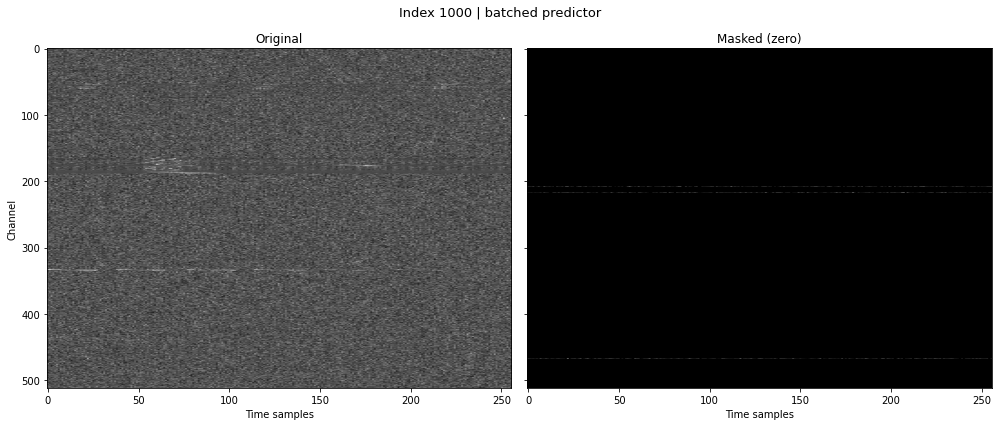

In [69]:
# Визуально проверить один сегмент без записи

data0, masked0, row_mask0, probs0 = plot_masked_segment(
    file_or_path=work_file,
    index=1000,
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    plot=True,
    title="| batched predictor",
)

In [57]:
# Записать один индекс и проверить round-trip

orig1, masked1, row_mask1, probs1 = write_one_masked_segment_to_fits(
    fits_file=work_file,
    index=691,
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    verify=True,
)

print(np.array_equal(masked0, masked1))
print(np.array_equal(row_mask0, row_mask1))

False
False


In [43]:
# Обработать несколько индексов

stats_some = mask_indices_in_fits(
    fits_file=work_file,
    indices=[10, 11, 12, 50, 51],
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    verify_every=1,
)

stats_some

Masking selected indices: 100%|██████████| 5/5 [00:00<00:00, 118.41segment/s, masked=511]
Exception ignored in: <function FITS_rec.__del__ at 0x2b9f0e1f1040>
Traceback (most recent call last):
  File "/home/user/miniconda/lib/python3.8/site-packages/astropy/io/fits/fitsrec.py", line 655, in __del__
    col.array = col.array.copy()
KeyboardInterrupt: 


,index,n_masked,frac_masked,prob_min,prob_mean,prob_max
0,10,510,0.996094,0.766760,0.997743,1.0
1,11,511,0.998047,0.853142,0.998083,1.0
2,12,512,1.000000,0.955509,0.998959,1.0
3,50,510,0.996094,0.789392,0.998053,1.0
4,51,511,0.998047,0.866989,0.998165,1.0


In [ ]:
# Обработать диапазон

stats_range = mask_index_range_in_fits(
    fits_file=work_file,
    index_start=100,
    index_stop=200,   # не включая 200
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    verify_every=20,
)

stats_range.head()

In [62]:
# Обработать весь файл

stats_full = mask_full_fits(
    fits_file=work_file,
    nsamp=256,
    predict_segment_fn=predict_segment_fn,
    filler=noise_mode,
    verify_every=None,   # для полного файла обычно выключаем
)

stats_full.head()

Masking full file:   0%|          | 9/36376 [00:00<07:12, 84.05segment/s, masked=56]

Masking full file: 100%|██████████| 36376/36376 [07:17<00:00, 83.09segment/s, masked=50] 


,index,n_masked,frac_masked,prob_min,prob_mean,prob_max
0,0,5,0.009766,0.008484,0.125903,0.990474
1,1,59,0.115234,0.003712,0.256573,0.999999
2,2,48,0.093750,0.001734,0.245742,0.999999
3,3,59,0.115234,0.002158,0.251143,0.999999
4,4,54,0.105469,0.002902,0.255179,0.999998
